In [1]:
#!/usr/bin/env python3
"""
=============================================================================
SCRIPT 1: B CELL LINEAGE — DONOR-LEVEL VALIDATION
=============================================================================
Claims to validate:
  1. PlasmaB/B ratio decline (NL 0.280 → CR 0.050)
  2. "Switched but Stuck" — class switch markers vs differentiation
  3. B cell clonality = 0.000 claim
  4. Myeloid → B cell tolerance circuit (LGALS9/TGFB1 on B cells)
  5. Key B cell functional genes

All comparisons: NL vs IT (primary), plus full 5-stage trajectory
=============================================================================
"""

!pip install -q scanpy leidenalg pyscenic gseapy openpyxl

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import scipy.sparse as sp
import os
import warnings
warnings.filterwarnings('ignore')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 139.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 100.2 MB/s eta 0:00:00
   ━━━━━

In [2]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# SETUP
# ============================================================
DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Loading dataset...")
adata = sc.read_h5ad(DATA_PATH)
print(f"Dataset: {adata.shape[0]} cells, {adata.shape[1]} genes")

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']
STAGE_COLORS = {'NL': 'forestgreen', 'IT': 'crimson', 'IA': 'darkorange',
                'AR': 'royalblue', 'CR': 'purple'}
np.random.seed(42)

Loading dataset...
Dataset: 243000 cells, 24452 genes


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================
def get_donor_means(adata_sub, gene_name):
    if gene_name not in adata_sub.var_names:
        return None
    if sp.issparse(adata_sub.X):
        expr = adata_sub[:, gene_name].X.toarray().flatten()
    else:
        expr = adata_sub[:, gene_name].X.flatten()
    df = pd.DataFrame({
        'expression': expr,
        'Stage': adata_sub.obs['Stage'].astype(str).values,
        'donor_id': adata_sub.obs['donor_id'].astype(str).values
    })
    return df.groupby(['donor_id', 'Stage'])['expression'].mean().reset_index()

def donor_test(donor_df, stage_a, stage_b):
    va = donor_df[donor_df['Stage'] == stage_a]['expression'].values
    vb = donor_df[donor_df['Stage'] == stage_b]['expression'].values
    if len(va) < 2 or len(vb) < 2:
        return {'va': va, 'vb': vb, 'p': 1.0, 'direction': 'NS',
                'consist': 0, 'total': 0, 'change': 0}
    _, p_gt = mannwhitneyu(va, vb, alternative='greater')
    _, p_lt = mannwhitneyu(va, vb, alternative='less')
    if p_gt < p_lt:
        consist = sum(1 for a in va for b in vb if a > b)
        direction = f'{stage_a}>{stage_b}'
        p_use = p_gt
    else:
        consist = sum(1 for a in va for b in vb if a < b)
        direction = f'{stage_b}>{stage_a}'
        p_use = p_lt
    total = len(va) * len(vb)
    change = (vb.mean() - va.mean()) / va.mean() * 100 if va.mean() > 0 else float('inf')
    return {'va': va, 'vb': vb, 'p': p_use, 'direction': direction,
            'consist': consist, 'total': total, 'change': change}

def plot_donor_dots(ax, donor_df, title, ylabel, stages=STAGE_ORDER):
    for i, stage in enumerate(stages):
        sd = donor_df[donor_df['Stage'] == stage]
        vals = []
        for _, row in sd.iterrows():
            jitter = np.random.uniform(-0.15, 0.15)
            ax.plot(i + jitter, row['expression'], 'o',
                    color=STAGE_COLORS[stage], markersize=8,
                    markeredgecolor='black', markeredgewidth=0.5, alpha=0.8)
            vals.append(row['expression'])
        if vals:
            ax.plot([i-0.25, i+0.25], [np.mean(vals)]*2, '-', color='black', lw=2.0)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, fontsize=10, fontweight='bold')
    for i, s in enumerate(stages):
        ax.get_xticklabels()[i].set_color(STAGE_COLORS[s])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def run_gene_battery(adata_sub, genes, lineage_name, comparisons, fig_title, save_name):
    """Run donor-level test for multiple genes across specified comparisons."""
    results = {}
    n_genes = len(genes)
    n_cols = min(4, n_genes)
    n_rows = (n_genes + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    fig.suptitle(fig_title, fontsize=13, fontweight='bold', y=1.0)

    for comp_name, (sa, sb) in comparisons.items():
        print(f"\n--- {lineage_name}: {comp_name} ---")
        print(f"  {'Gene':<12s} {sa+' mean':>10s} {sb+' mean':>10s} {'Change':>10s} "
              f"{'Direction':>12s} {'Consist':>10s} {'p-value':>10s}")
        print("  " + "-"*78)

        for idx, gene in enumerate(genes):
            donor_df = get_donor_means(adata_sub, gene)
            if donor_df is None:
                print(f"  {gene:<12s}: NOT FOUND")
                continue
            result = donor_test(donor_df, sa, sb)
            sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""
            change_str = f"{result['change']:+.1f}%" if abs(result['change']) < 9999 else "INF"
            print(f"  {gene:<12s} {result['va'].mean():>10.4f} {result['vb'].mean():>10.4f} "
                  f"{change_str:>10s} {result['direction']:>12s} "
                  f"{result['consist']}/{result['total']:>7} {result['p']:>10.3f}{sig}")
            results[f"{comp_name}_{gene}"] = result

            # Plot for primary comparison only
            if comp_name == list(comparisons.keys())[0]:
                r, c = idx // n_cols, idx % n_cols
                ax = axes[r, c]
                plot_donor_dots(ax, donor_df,
                                f'{gene}\n({sa}→{sb}: {change_str})',
                                f'{gene}')
                pcolor = 'darkred' if result['p'] < 0.05 else 'darkblue' if result['p'] < 0.1 else 'grey'
                label = f'{result["consist"]}/{result["total"]}, p={result["p"]:.3f}'
                ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=8,
                        ha='right', va='top', color=pcolor, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                                  alpha=0.8, edgecolor='grey'))

    # Hide unused axes
    for idx in range(len(genes), n_rows * n_cols):
        r, c = idx // n_cols, idx % n_cols
        axes[r, c].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, f'{save_name}.png'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(SAVE_DIR, f'{save_name}.pdf'), bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_name}")
    return results

In [6]:
# 🔴 CRITICAL: 'processed' subfolder 포함 확인!
PROJECT_ROOT = '/content/drive/MyDrive/ITLAS'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed')   # ← processed 빠뜨리지 말 것
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'results')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')
TABLES_DIR   = os.path.join(RESULTS_DIR, 'tables')

# h5ad 파일 경로
H5AD_PATH = os.path.join(DATA_DIR, 'GSE182159_gut2021_annotated.h5ad')

# --- Step 4: Verify paths exist ---
print("=" * 60)
print("PATH VERIFICATION")
print("=" * 60)

paths_to_check = {
    'PROJECT_ROOT': PROJECT_ROOT,
    'DATA_DIR':     DATA_DIR,
    'RESULTS_DIR':  RESULTS_DIR,
    'H5AD_PATH':    H5AD_PATH,
}

all_ok = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status}  {name:15s} = {path}")
    if not exists:
        all_ok = False

# --- Step 5: If h5ad not found, search for it ---
if not os.path.exists(H5AD_PATH):
    print("\n⚠️  H5AD file not found at expected path. Searching...")
    import glob
    candidates = glob.glob(os.path.join(PROJECT_ROOT, '**', '*.h5ad'), recursive=True)
    if candidates:
        for c in candidates:
            size_gb = os.path.getsize(c) / (1024**3)
            print(f"  Found: {c} ({size_gb:.2f} GB)")
        print("\n  → H5AD_PATH를 위 경로 중 하나로 수정하세요.")
    else:
        print("  ❌ No .h5ad files found in ITLAS folder!")

# --- Step 6: Create output directories ---
for d in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

if all_ok:
    print("\n✅ 모든 경로 확인 완료. 다음 셀로 진행 가능.")
else:
    print("\n🔴 경로 문제 해결 후 다음 셀로 진행하세요.")

PATH VERIFICATION
  ✅  PROJECT_ROOT    = /content/drive/MyDrive/ITLAS
  ✅  DATA_DIR        = /content/drive/MyDrive/ITLAS/data/processed
  ✅  RESULTS_DIR     = /content/drive/MyDrive/ITLAS/results
  ✅  H5AD_PATH       = /content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad

✅ 모든 경로 확인 완료. 다음 셀로 진행 가능.


In [7]:
# ============================================================
# 00_ITLAS_Setup.ipynb — Cell 3
# Donor ID Extraction + AUCell Score File Search
# ============================================================

# ═══════════════════════════════════════════════════════════
# PART A: Donor ID 추출
# ═══════════════════════════════════════════════════════════
# sample 값 예: 'GSM5519467_P190604_Blood_1'
# → Patient ID = 'P190604' (두 번째 필드)

# 먼저 sample 값 구조 확인
print("=" * 60)
print("PART A: DONOR ID EXTRACTION")
print("=" * 60)
print("\nSample values (처음 10개):")
for val in adata.obs['sample'].unique()[:10]:
    parts = str(val).split('_')
    print(f"  {val}")
    print(f"    → parts: {parts}")

# Patient ID 추출 시도
# 패턴: GSM5519467_P190604_Blood_1 → P190604
adata.obs['donor_id'] = adata.obs['sample'].astype(str).apply(
    lambda x: x.split('_')[1] if len(x.split('_')) >= 2 else x
)

n_donors = adata.obs['donor_id'].nunique()
print(f"\n추출된 donor_id unique 수: {n_donors}")
print(f"기대값: 23")

if n_donors == 23:
    print("✅ 23 donors 정확히 추출됨!")
else:
    print(f"⚠️  {n_donors}명 → 수동 확인 필요")

# Donor × Stage 교차표
print("\n📊 Donor × Stage 교차표 (cell counts):")
ct = pd.crosstab(adata.obs['donor_id'], adata.obs['Stage'])
# Stage 순서 정렬
stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
ct = ct.reindex(columns=[s for s in stage_order if s in ct.columns])
print(ct.to_string())

# 각 Stage별 donor 수
print("\n📊 Donors per Stage:")
for stage in stage_order:
    donors_in_stage = adata.obs[adata.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"   {stage}: n = {donors_in_stage}")

# ═══════════════════════════════════════════════════════════
# PART B: AUCell 26 Pathway 점수 파일 탐색
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PART B: AUCell SCORE FILE SEARCH")
print("=" * 60)

import glob

# 검색 패턴: AUCell 관련 파일
search_patterns = [
    os.path.join(PROJECT_ROOT, '**', '*aucell*'),
    os.path.join(PROJECT_ROOT, '**', '*AUCell*'),
    os.path.join(PROJECT_ROOT, '**', '*pathway*score*'),
    os.path.join(PROJECT_ROOT, '**', '*26_pathway*'),
    os.path.join(PROJECT_ROOT, '**', '*inflammasome*'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.csv'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.pkl'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.parquet'),
    os.path.join(PROJECT_ROOT, 'data', '**', '*.csv'),
]

found_files = set()
for pattern in search_patterns:
    for f in glob.glob(pattern, recursive=True):
        found_files.add(f)

if found_files:
    print(f"\n발견된 관련 파일 ({len(found_files)}개):")
    for f in sorted(found_files):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  {f} ({size_mb:.1f} MB)")
else:
    print("\n❌ AUCell 관련 파일을 찾지 못했습니다.")

# 혹시 다른 h5ad 파일에 AUCell이 포함되어 있을 수 있음
print("\n📋 다른 h5ad 파일 탐색:")
h5ad_files = glob.glob(os.path.join(PROJECT_ROOT, '**', '*.h5ad'), recursive=True)
for f in h5ad_files:
    size_gb = os.path.getsize(f) / (1024**3)
    print(f"  {f} ({size_gb:.2f} GB)")

# adata.obsm 확인 (AUCell이 여기 저장되었을 수 있음)
print(f"\n📋 adata.obsm keys: {list(adata.obsm.keys())}")

# adata.uns 확인
print(f"📋 adata.uns keys (상위): {list(adata.uns.keys())[:20]}")

# ═══════════════════════════════════════════════════════════
# PART C: 현재 상태 요약
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SUMMARY: 다음 단계 결정을 위한 현재 상태")
print("=" * 60)

available_pw = [c for c in adata.obs.columns if c.startswith('PW_')]
print(f"\n현재 obs에 있는 PW 컬럼 ({len(available_pw)}개): {available_pw}")

missing_pw = [
    'Inflammasome', 'Immune_Evasion', 'Checkpoint', 'Exhaustion',
    'NK_Function', 'Senescence', 'Cancer_Associated', 'Cytotoxicity',
    'Treg', 'Naive_T', 'Memory_T', 'TF_Programs', 'Tissue_Resident',
    'Stemness', 'Apoptosis', 'Fibrosis', 'Epigenetics', 'Angiogenesis',
    'Cell_cycle_Proliferation', 'MITO_DYSFUNCTION', 'Metabolic_Recovery'
]
print(f"누락된 핵심 pathway ({len(missing_pw)}개): {missing_pw[:8]}...")
print(f"\n⚠️  결과를 확인 후 알려주세요:")
print(f"   1) Donor ID가 23명 맞는지")
print(f"   2) AUCell 파일이 어디에 있는지 (또는 재계산 필요한지)")

PART A: DONOR ID EXTRACTION

Sample values (처음 10개):
  GSM5519467_P190604_Blood_1
    → parts: ['GSM5519467', 'P190604', 'Blood', '1']
  GSM5519468_P190604_Blood_2
    → parts: ['GSM5519468', 'P190604', 'Blood', '2']
  GSM5519469_P190604_Liver_1
    → parts: ['GSM5519469', 'P190604', 'Liver', '1']
  GSM5519470_P190326_Blood_1
    → parts: ['GSM5519470', 'P190326', 'Blood', '1']
  GSM5519471_P190326_Liver_1
    → parts: ['GSM5519471', 'P190326', 'Liver', '1']
  GSM5519472_P190402_Liver_1
    → parts: ['GSM5519472', 'P190402', 'Liver', '1']
  GSM5519473_P190716_Blood_1
    → parts: ['GSM5519473', 'P190716', 'Blood', '1']
  GSM5519474_P190716_Blood_2
    → parts: ['GSM5519474', 'P190716', 'Blood', '2']
  GSM5519475_P190716_Liver_1
    → parts: ['GSM5519475', 'P190716', 'Liver', '1']
  GSM5519476_P190719_Blood_1
    → parts: ['GSM5519476', 'P190719', 'Blood', '1']

추출된 donor_id unique 수: 23
기대값: 23
✅ 23 donors 정확히 추출됨!

📊 Donor × Stage 교차표 (cell counts):
Stage        NL     IT     IA     A

In [8]:
# ============================================================
# 00_ITLAS_Setup.ipynb — Cell 2
# Load h5ad & Explore obs columns
# ============================================================
# 목적: DONOR_COL, STAGE_COL, LINEAGE_COL, SUBCLUSTER_COL 정확한 이름 확인
# ⚠️ KeyError: None 방지 — 이 셀에서 확인 후 Cell 3에서 확정

# --- Step 1: Load data ---
print("Loading h5ad... (1-2분 소요)")
adata = sc.read_h5ad(H5AD_PATH)
print(f"✅ Loaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")

# --- Step 2: ALL obs columns 전체 출력 ---
print("\n" + "=" * 70)
print("ALL COLUMNS IN adata.obs")
print("=" * 70)
for i, col in enumerate(adata.obs.columns.tolist()):
    nuniq = adata.obs[col].nunique()
    dtype = str(adata.obs[col].dtype)
    # 샘플값 (문자열로 변환하여 안전하게)
    samples = [str(x) for x in adata.obs[col].unique()[:5]]
    print(f"  {i+1:3d}. {col:35s} | {dtype:12s} | unique={nuniq:5d} | {samples}")

# --- Step 3: Stage/Group 컬럼 자동 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: STAGE / GROUP COLUMN")
print("=" * 70)
for col in adata.obs.columns:
    vals = set(adata.obs[col].astype(str).unique())
    # NL, IT, IA, AR 중 3개 이상 포함하면 stage 컬럼일 가능성 높음
    stage_markers = {'NL', 'IT', 'IA', 'AR'}
    overlap = vals & stage_markers
    if len(overlap) >= 3:
        print(f"  🎯 '{col}' → contains {overlap}")
        print(f"     All values: {sorted(vals)}")
        # 🔴 CR vs AC 확인!
        if 'AC' in vals:
            print(f"     ⚠️  'AC' detected! (원본 데이터 = AC, 우리 논문 = CR)")
        if 'CR' in vals:
            print(f"     ✅ 'CR' confirmed (이미 변환됨)")

# --- Step 4: Donor/Sample 컬럼 자동 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: DONOR / SAMPLE COLUMN")
print("=" * 70)
for col in adata.obs.columns:
    nuniq = adata.obs[col].nunique()
    # 23 donors 또는 그 근처
    if 15 <= nuniq <= 30:
        print(f"  🔍 '{col}' → {nuniq} unique values (23 donors expected)")
        print(f"     Sample: {adata.obs[col].unique()[:8].tolist()}")

# --- Step 5: Lineage / Celltype 컬럼 자동 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: LINEAGE / CELLTYPE COLUMN")
print("=" * 70)
for col in adata.obs.columns:
    nuniq = adata.obs[col].nunique()
    vals_str = [str(x).lower() for x in adata.obs[col].unique()[:20]]
    vals_joined = ' '.join(vals_str)
    # 7-8 lineages 또는 59-60 subclusters
    if 5 <= nuniq <= 12 and any(k in vals_joined for k in ['nk', 'myeloid', 'cd4', 'cd8', 'b ']):
        print(f"  🎯 LINEAGE: '{col}' → {nuniq} values")
        print(f"     Values: {sorted(adata.obs[col].unique().tolist())}")
    if 55 <= nuniq <= 65:
        print(f"  🎯 SUBCLUSTER: '{col}' → {nuniq} values")
        print(f"     Sample: {adata.obs[col].unique()[:10].tolist()}")

# --- Step 6: AUCell score 컬럼 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: AUCell PATHWAY SCORE COLUMNS")
print("=" * 70)
aucell_cols = []
for col in adata.obs.columns:
    if adata.obs[col].dtype in ['float32', 'float64'] and adata.obs[col].nunique() > 100:
        aucell_cols.append(col)

if aucell_cols:
    print(f"  Found {len(aucell_cols)} numeric columns (potential AUCell scores):")
    for col in aucell_cols[:30]:
        mean_val = adata.obs[col].mean()
        print(f"    {col:40s} | mean={mean_val:.4f}")
else:
    print("  ❌ No obvious AUCell columns found in obs")
    print("  → adata.obsm keys:", list(adata.obsm.keys()) if adata.obsm else "empty")

print("\n" + "=" * 70)
print("⚠️  위 출력을 확인하고 Cell 3에서 정확한 컬럼명을 확정합니다.")
print("=" * 70)

Loading h5ad... (1-2분 소요)
✅ Loaded: 243,000 cells × 24,452 genes

ALL COLUMNS IN adata.obs
    1. sample                              | category     | unique=   46 | ['GSM5519467_P190604_Blood_1', 'GSM5519468_P190604_Blood_2', 'GSM5519469_P190604_Liver_1', 'GSM5519470_P190326_Blood_1', 'GSM5519471_P190326_Liver_1']
    2. tissue                              | category     | unique=    2 | ['Blood', 'Liver']
    3. Stage                               | category     | unique=    5 | ['IT', 'AR', 'IA', 'NL', 'CR']
    4. IT_cluster_21                       | float64      | unique=242960 | ['3.7056410722019946', '4.034355906879201', '3.1085649192427978', '3.244250415808067', '4.0003165929609334']
    5. IT_cluster_23                       | float64      | unique=240984 | ['3.262586739225295', '3.6219994132958573', '2.7674797842803516', '2.320434523091733', '3.5876710363962117']
    6. IT_cluster_25                       | float64      | unique=114299 | ['4.199094219154806', '0.0', '1.71414

In [9]:
# ============================================================
# 00_ITLAS_Setup.ipynb — Cell 3
# Donor ID Extraction + AUCell Score File Search
# ============================================================

# ═══════════════════════════════════════════════════════════
# PART A: Donor ID 추출
# ═══════════════════════════════════════════════════════════
# sample 값 예: 'GSM5519467_P190604_Blood_1'
# → Patient ID = 'P190604' (두 번째 필드)

# 먼저 sample 값 구조 확인
print("=" * 60)
print("PART A: DONOR ID EXTRACTION")
print("=" * 60)
print("\nSample values (처음 10개):")
for val in adata.obs['sample'].unique()[:10]:
    parts = str(val).split('_')
    print(f"  {val}")
    print(f"    → parts: {parts}")

# Patient ID 추출 시도
# 패턴: GSM5519467_P190604_Blood_1 → P190604
adata.obs['donor_id'] = adata.obs['sample'].astype(str).apply(
    lambda x: x.split('_')[1] if len(x.split('_')) >= 2 else x
)

n_donors = adata.obs['donor_id'].nunique()
print(f"\n추출된 donor_id unique 수: {n_donors}")
print(f"기대값: 23")

if n_donors == 23:
    print("✅ 23 donors 정확히 추출됨!")
else:
    print(f"⚠️  {n_donors}명 → 수동 확인 필요")

# Donor × Stage 교차표
print("\n📊 Donor × Stage 교차표 (cell counts):")
ct = pd.crosstab(adata.obs['donor_id'], adata.obs['Stage'])
# Stage 순서 정렬
stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
ct = ct.reindex(columns=[s for s in stage_order if s in ct.columns])
print(ct.to_string())

# 각 Stage별 donor 수
print("\n📊 Donors per Stage:")
for stage in stage_order:
    donors_in_stage = adata.obs[adata.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"   {stage}: n = {donors_in_stage}")

# ═══════════════════════════════════════════════════════════
# PART B: AUCell 26 Pathway 점수 파일 탐색
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PART B: AUCell SCORE FILE SEARCH")
print("=" * 60)

import glob

# 검색 패턴: AUCell 관련 파일
search_patterns = [
    os.path.join(PROJECT_ROOT, '**', '*aucell*'),
    os.path.join(PROJECT_ROOT, '**', '*AUCell*'),
    os.path.join(PROJECT_ROOT, '**', '*pathway*score*'),
    os.path.join(PROJECT_ROOT, '**', '*26_pathway*'),
    os.path.join(PROJECT_ROOT, '**', '*inflammasome*'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.csv'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.pkl'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.parquet'),
    os.path.join(PROJECT_ROOT, 'data', '**', '*.csv'),
]

found_files = set()
for pattern in search_patterns:
    for f in glob.glob(pattern, recursive=True):
        found_files.add(f)

if found_files:
    print(f"\n발견된 관련 파일 ({len(found_files)}개):")
    for f in sorted(found_files):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  {f} ({size_mb:.1f} MB)")
else:
    print("\n❌ AUCell 관련 파일을 찾지 못했습니다.")

# 혹시 다른 h5ad 파일에 AUCell이 포함되어 있을 수 있음
print("\n📋 다른 h5ad 파일 탐색:")
h5ad_files = glob.glob(os.path.join(PROJECT_ROOT, '**', '*.h5ad'), recursive=True)
for f in h5ad_files:
    size_gb = os.path.getsize(f) / (1024**3)
    print(f"  {f} ({size_gb:.2f} GB)")

# adata.obsm 확인 (AUCell이 여기 저장되었을 수 있음)
print(f"\n📋 adata.obsm keys: {list(adata.obsm.keys())}")

# adata.uns 확인
print(f"📋 adata.uns keys (상위): {list(adata.uns.keys())[:20]}")

# ═══════════════════════════════════════════════════════════
# PART C: 현재 상태 요약
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SUMMARY: 다음 단계 결정을 위한 현재 상태")
print("=" * 60)

available_pw = [c for c in adata.obs.columns if c.startswith('PW_')]
print(f"\n현재 obs에 있는 PW 컬럼 ({len(available_pw)}개): {available_pw}")

missing_pw = [
    'Inflammasome', 'Immune_Evasion', 'Checkpoint', 'Exhaustion',
    'NK_Function', 'Senescence', 'Cancer_Associated', 'Cytotoxicity',
    'Treg', 'Naive_T', 'Memory_T', 'TF_Programs', 'Tissue_Resident',
    'Stemness', 'Apoptosis', 'Fibrosis', 'Epigenetics', 'Angiogenesis',
    'Cell_cycle_Proliferation', 'MITO_DYSFUNCTION', 'Metabolic_Recovery'
]
print(f"누락된 핵심 pathway ({len(missing_pw)}개): {missing_pw[:8]}...")
print(f"\n⚠️  결과를 확인 후 알려주세요:")
print(f"   1) Donor ID가 23명 맞는지")
print(f"   2) AUCell 파일이 어디에 있는지 (또는 재계산 필요한지)")

PART A: DONOR ID EXTRACTION

Sample values (처음 10개):
  GSM5519467_P190604_Blood_1
    → parts: ['GSM5519467', 'P190604', 'Blood', '1']
  GSM5519468_P190604_Blood_2
    → parts: ['GSM5519468', 'P190604', 'Blood', '2']
  GSM5519469_P190604_Liver_1
    → parts: ['GSM5519469', 'P190604', 'Liver', '1']
  GSM5519470_P190326_Blood_1
    → parts: ['GSM5519470', 'P190326', 'Blood', '1']
  GSM5519471_P190326_Liver_1
    → parts: ['GSM5519471', 'P190326', 'Liver', '1']
  GSM5519472_P190402_Liver_1
    → parts: ['GSM5519472', 'P190402', 'Liver', '1']
  GSM5519473_P190716_Blood_1
    → parts: ['GSM5519473', 'P190716', 'Blood', '1']
  GSM5519474_P190716_Blood_2
    → parts: ['GSM5519474', 'P190716', 'Blood', '2']
  GSM5519475_P190716_Liver_1
    → parts: ['GSM5519475', 'P190716', 'Liver', '1']
  GSM5519476_P190719_Blood_1
    → parts: ['GSM5519476', 'P190719', 'Blood', '1']

추출된 donor_id unique 수: 23
기대값: 23
✅ 23 donors 정확히 추출됨!

📊 Donor × Stage 교차표 (cell counts):
Stage        NL     IT     IA     A

In [10]:
# ============================================================
# GET SUBSETS
# ============================================================
b_mask = adata.obs['major_lineage'] == 'B'
pb_mask = adata.obs['major_lineage'] == 'PlasmaB'
adata_b = adata[b_mask]
adata_pb = adata[pb_mask]
adata_b_combined = adata[b_mask | pb_mask]

print("\n" + "="*80)
print("B CELL SUBSET")
print("="*80)
for stage in STAGE_ORDER:
    nb = (adata_b.obs['Stage'] == stage).sum()
    npb = (adata_pb.obs['Stage'] == stage).sum()
    db = adata_b.obs[adata_b.obs['Stage'] == stage]['donor_id'].nunique()
    dpb = adata_pb.obs[adata_pb.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"  {stage}: B={nb} cells ({db} donors), PlasmaB={npb} cells ({dpb} donors)")


B CELL SUBSET
  NL: B=2510 cells (6 donors), PlasmaB=702 cells (6 donors)
  IT: B=4007 cells (6 donors), PlasmaB=365 cells (6 donors)
  IA: B=5219 cells (5 donors), PlasmaB=358 cells (5 donors)
  AR: B=2326 cells (3 donors), PlasmaB=292 cells (3 donors)
  CR: B=7263 cells (3 donors), PlasmaB=366 cells (3 donors)



PART 1: PlasmaB/B RATIO — DONOR-LEVEL

PlasmaB/(B+PlasmaB) ratio by stage (donor-level):
  NL: ratio = 0.079 ± 0.194 (n=23 donors, range: 0.000-0.732)
  IT: ratio = 0.024 ± 0.045 (n=23 donors, range: 0.000-0.161)
  IA: ratio = 0.019 ± 0.044 (n=23 donors, range: 0.000-0.170)
  AR: ratio = 0.014 ± 0.042 (n=23 donors, range: 0.000-0.174)
  CR: ratio = 0.006 ± 0.016 (n=23 donors, range: 0.000-0.051)
  NL→IT: -69.6%, NL>IT: 125/529, p=0.449
  NL→CR: -92.2%, NL>CR: 132/529, p=0.120
  IT→CR: -74.2%, IT>CR: 138/529, p=0.086 *


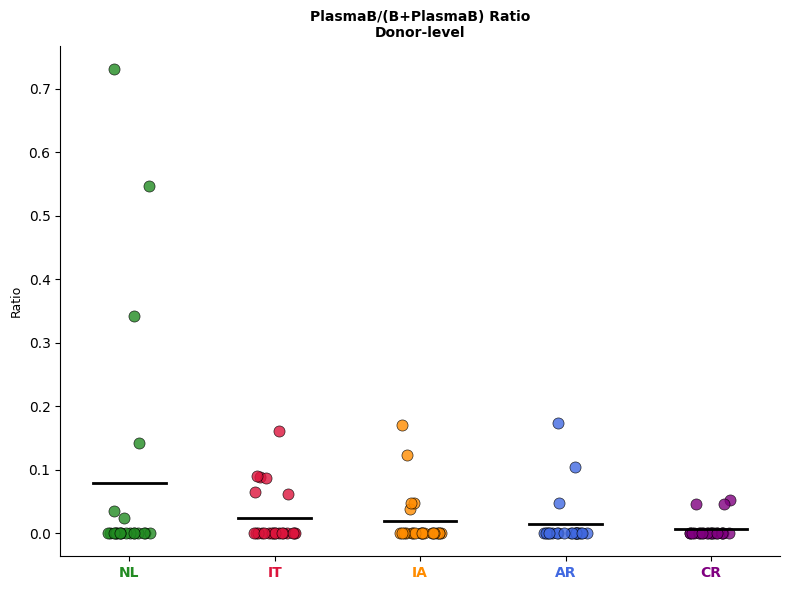

Saved: PlasmaB/B ratio


In [11]:
# ============================================================
# PART 1: PlasmaB/B RATIO — Donor-level
# ============================================================
print("\n" + "="*80)
print("PART 1: PlasmaB/B RATIO — DONOR-LEVEL")
print("="*80)

# Count cells per donor per stage per lineage
counts = adata_b_combined.obs.groupby(
    ['donor_id', 'Stage', 'major_lineage']
).size().reset_index(name='n_cells')

ratio_records = []
for (donor, stage), grp in counts.groupby(['donor_id', 'Stage']):
    b_count = grp[grp['major_lineage'] == 'B']['n_cells'].sum()
    pb_count = grp[grp['major_lineage'] == 'PlasmaB']['n_cells'].sum()
    total = b_count + pb_count
    ratio = pb_count / total if total > 0 else 0
    ratio_records.append({
        'donor_id': donor, 'Stage': stage,
        'B_count': b_count, 'PlasmaB_count': pb_count,
        'total': total, 'expression': ratio  # 'expression' for plot_donor_dots
    })

ratio_df = pd.DataFrame(ratio_records)

print("\nPlasmaB/(B+PlasmaB) ratio by stage (donor-level):")
for stage in STAGE_ORDER:
    sd = ratio_df[ratio_df['Stage'] == stage]
    if len(sd) > 0:
        print(f"  {stage}: ratio = {sd['expression'].mean():.3f} ± {sd['expression'].std():.3f} "
              f"(n={len(sd)} donors, range: {sd['expression'].min():.3f}-{sd['expression'].max():.3f})")

# Test NL vs IT, NL vs CR
for sa, sb in [('NL', 'IT'), ('NL', 'CR'), ('IT', 'CR')]:
    result = donor_test(ratio_df, sa, sb)
    sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""
    print(f"  {sa}→{sb}: {result['change']:+.1f}%, {result['direction']}: "
          f"{result['consist']}/{result['total']}, p={result['p']:.3f}{sig}")

fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))
plot_donor_dots(ax1, ratio_df, 'PlasmaB/(B+PlasmaB) Ratio\nDonor-level', 'Ratio')
plt.tight_layout()
fig1.savefig(os.path.join(SAVE_DIR, 'SupFig_PlasmaB_B_Ratio_DonorLevel.png'),
             dpi=300, bbox_inches='tight')
fig1.savefig(os.path.join(SAVE_DIR, 'SupFig_PlasmaB_B_Ratio_DonorLevel.pdf'),
             bbox_inches='tight')
plt.show()
print("Saved: PlasmaB/B ratio")



PART 2: B CELL KEY GENES
Found: 17/17

--- B cell: NL_vs_IT ---
  Gene            NL mean    IT mean     Change    Direction    Consist    p-value
  ------------------------------------------------------------------------------
  IGHG1            0.1841     0.3162     +71.8%        IT>NL 29/     36      0.047 **
  IGHA1            0.4143     0.5309     +28.1%        IT>NL 23/     36      0.242
  IGHM             1.1692     1.5256     +30.5%        IT>NL 28/     36      0.066 *
  IGHD             0.5155     0.6058     +17.5%        IT>NL 23/     36      0.242
  SDC1             0.0000     0.0000        INF        IT>NL 0/     36      1.000
  PRDM1            0.0332     0.0165     -50.2%        NL>IT 24/     36      0.189
  XBP1             0.1972     0.2676     +35.7%        IT>NL 27/     36      0.090 *
  IRF4             0.1661     0.1552      -6.5%        NL>IT 19/     36      0.469
  CD27             0.2317     0.3890     +67.9%        IT>NL 29/     36      0.047 **
  CD38         

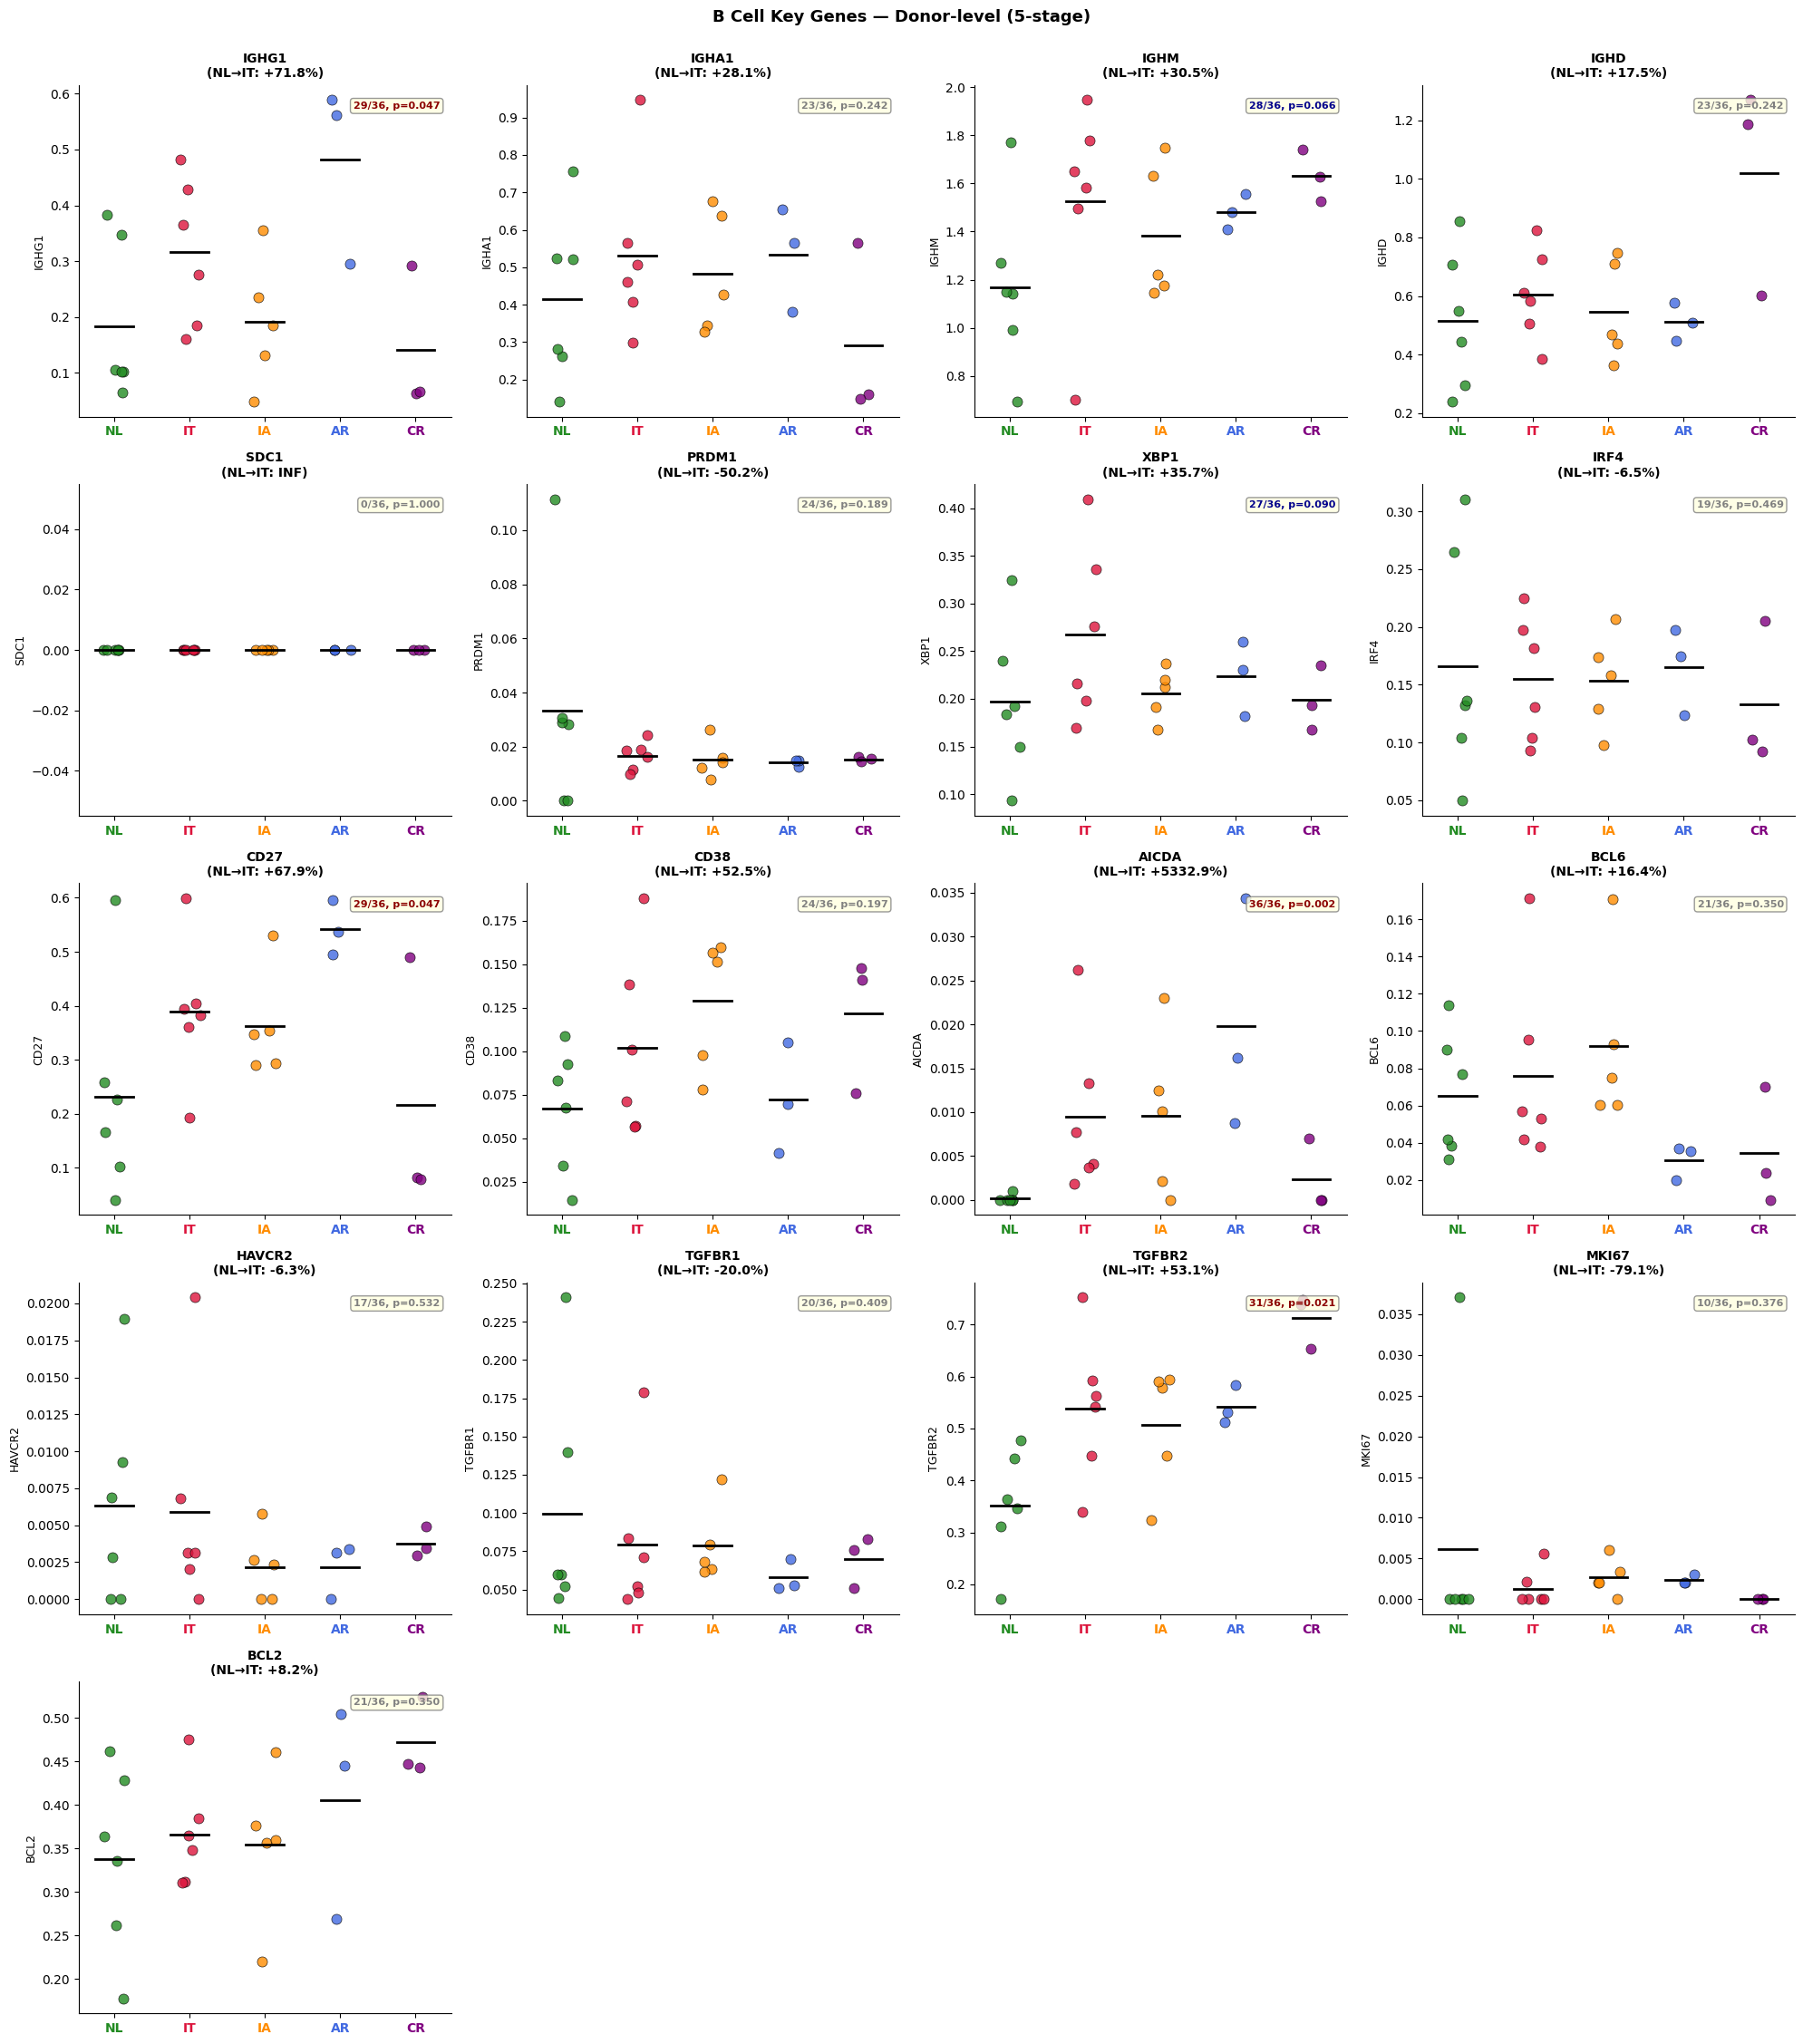

  Saved: SupFig_Bcell_KeyGenes_DonorLevel


In [12]:
# ============================================================
# PART 2: B CELL KEY GENES — Donor-level
# ============================================================
print("\n" + "="*80)
print("PART 2: B CELL KEY GENES")
print("="*80)

# Class switch / differentiation / tolerance markers
B_GENES = [
    # Class switch markers
    'IGHG1', 'IGHA1', 'IGHM', 'IGHD',
    # Differentiation
    'SDC1', 'PRDM1', 'XBP1', 'IRF4',
    # Tolerance / exhaustion
    'CD27', 'CD38', 'AICDA', 'BCL6',
    # Receptors for tolerance signals
    'HAVCR2', 'TGFBR1', 'TGFBR2',
    # Survival / proliferation
    'MKI67', 'BCL2',
]

# Filter to genes that exist
b_genes_exist = [g for g in B_GENES if g in adata_b.var_names]
b_genes_missing = [g for g in B_GENES if g not in adata_b.var_names]
print(f"Found: {len(b_genes_exist)}/{len(B_GENES)}")
if b_genes_missing:
    print(f"Missing: {b_genes_missing}")

comparisons = {'NL_vs_IT': ('NL', 'IT'), 'NL_vs_CR': ('NL', 'CR')}
b_results = run_gene_battery(adata_b, b_genes_exist, 'B cell', comparisons,
                              'B Cell Key Genes — Donor-level (5-stage)',
                              'SupFig_Bcell_KeyGenes_DonorLevel')



PART 3: PlasmaB KEY GENES
Found: 10/10

--- PlasmaB: NL_vs_IT ---
  Gene            NL mean    IT mean     Change    Direction    Consist    p-value
  ------------------------------------------------------------------------------
  SDC1             0.2952     0.1419     -51.9%        NL>IT 27/     36      0.090 *
  PRDM1            0.7192     0.3661     -49.1%        NL>IT 35/     36      0.002 **
  XBP1             2.0842     1.8882      -9.4%        NL>IT 23/     36      0.242
  IRF4             0.5674     1.1590    +104.3%        IT>NL 31/     36      0.021 **
  MKI67            0.0729     0.0626     -14.1%        IT>NL 19/     36      0.469
  IGHG1            1.4858     0.9421     -36.6%        NL>IT 27/     36      0.090 *
  IGHA1            1.6271     1.0753     -33.9%        NL>IT 30/     36      0.032 **
  JCHAIN           4.4084     3.6664     -16.8%        NL>IT 33/     36      0.008 **
  CD38             0.9626     0.6443     -33.1%        NL>IT 30/     36      0.032 **
  B

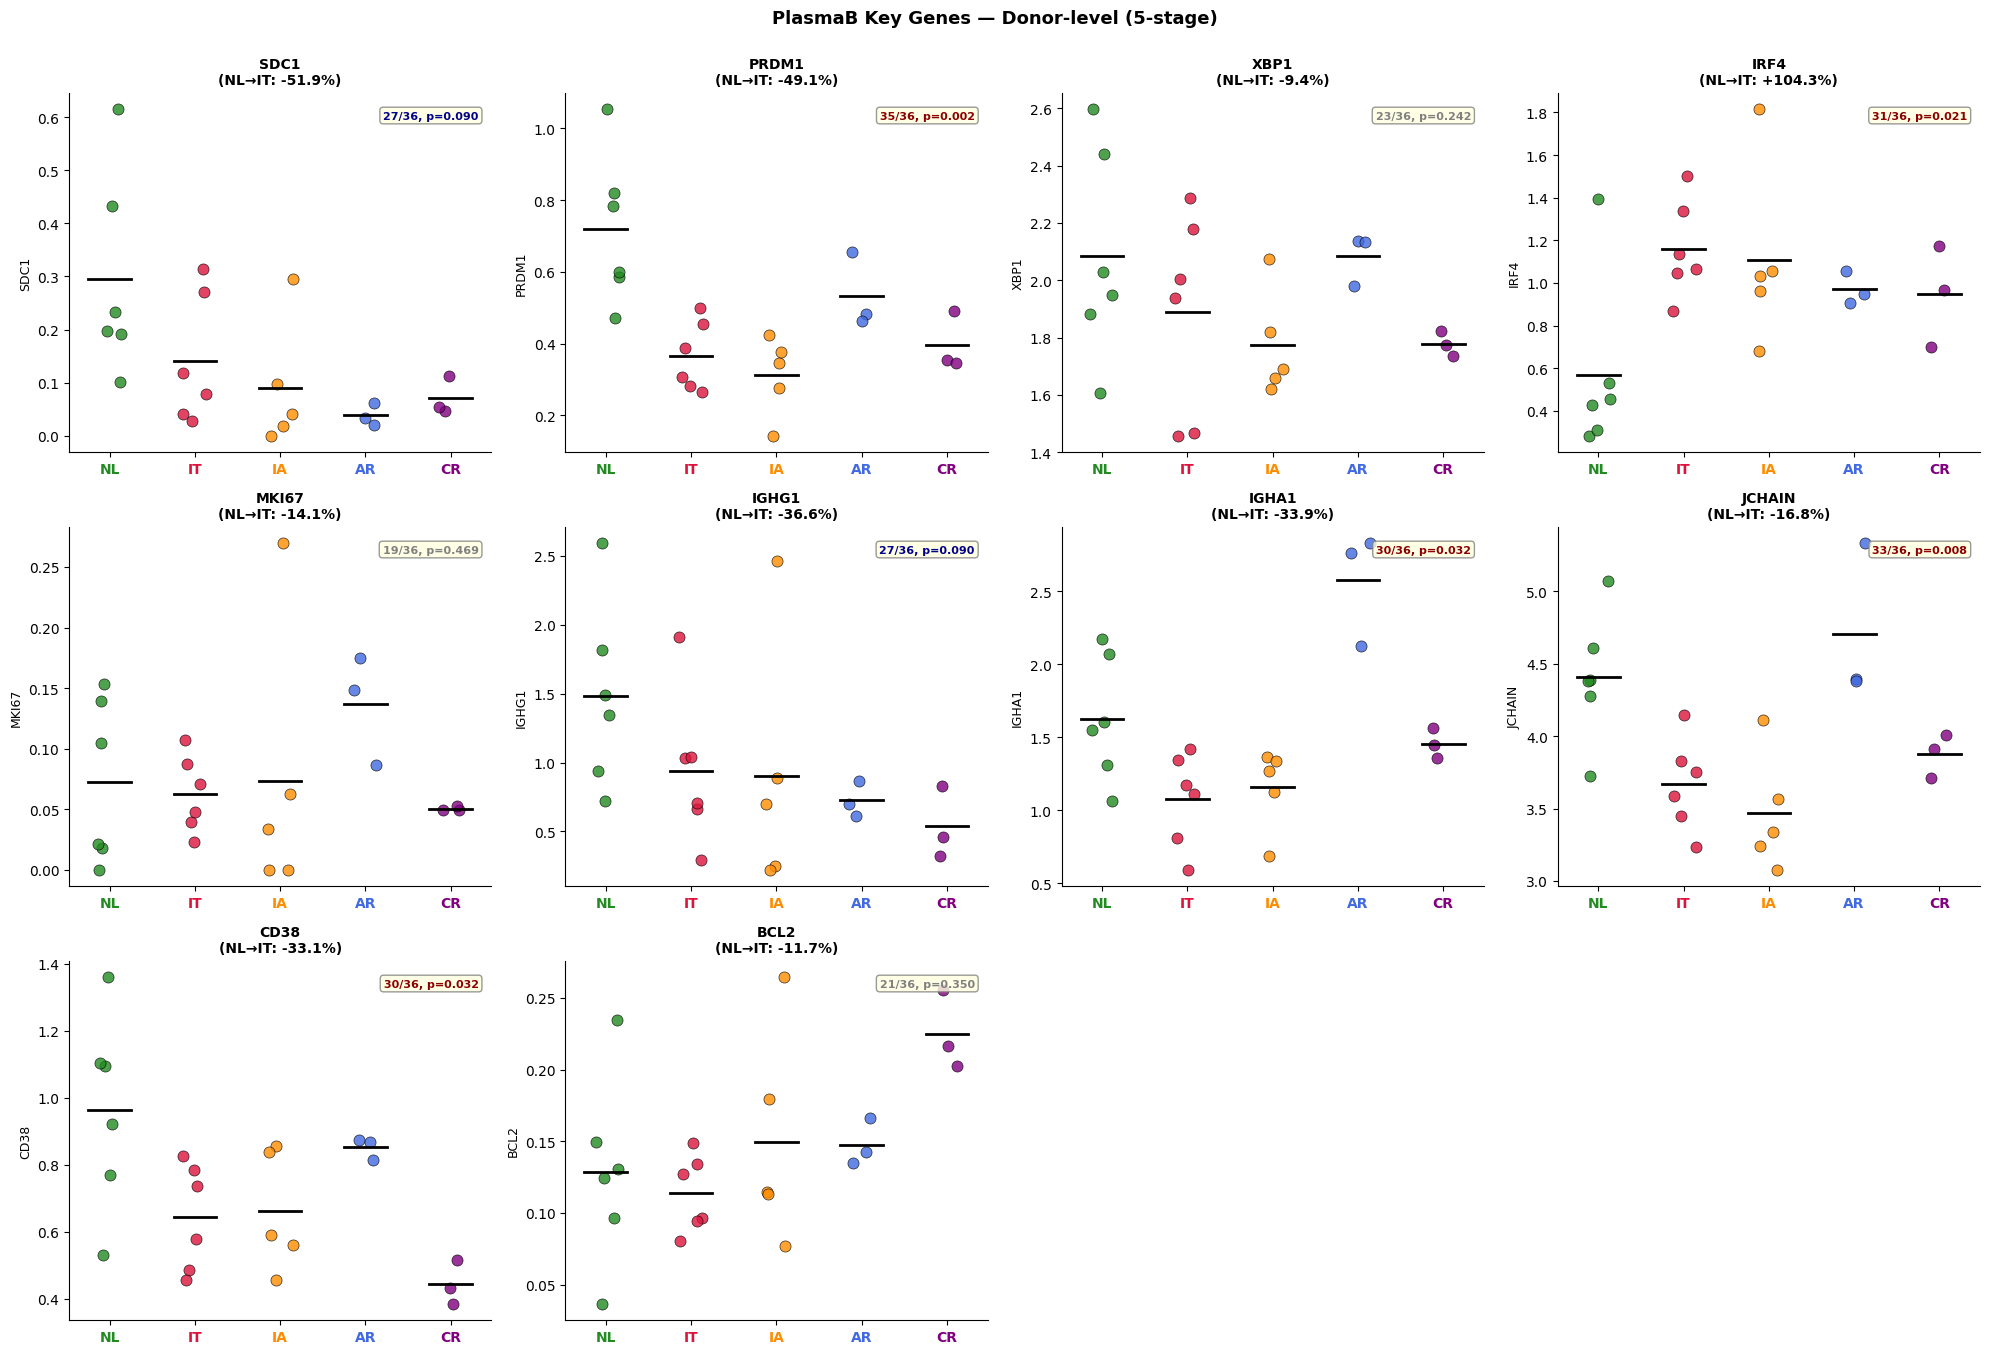

  Saved: SupFig_PlasmaB_KeyGenes_DonorLevel


In [13]:
# ============================================================
# PART 3: PlasmaB KEY GENES — Donor-level
# ============================================================
print("\n" + "="*80)
print("PART 3: PlasmaB KEY GENES")
print("="*80)

PB_GENES = ['SDC1', 'PRDM1', 'XBP1', 'IRF4', 'MKI67',
            'IGHG1', 'IGHA1', 'JCHAIN', 'CD38', 'BCL2']

pb_genes_exist = [g for g in PB_GENES if g in adata_pb.var_names]
pb_genes_missing = [g for g in PB_GENES if g not in adata_pb.var_names]
print(f"Found: {len(pb_genes_exist)}/{len(PB_GENES)}")
if pb_genes_missing:
    print(f"Missing: {pb_genes_missing}")

if len(pb_genes_exist) > 0:
    pb_results = run_gene_battery(adata_pb, pb_genes_exist, 'PlasmaB', comparisons,
                                   'PlasmaB Key Genes — Donor-level (5-stage)',
                                   'SupFig_PlasmaB_KeyGenes_DonorLevel')


PART 4: TOLERANCE CIRCUIT GENES ON B CELLS
        (Do B cells receive LGALS9/TGFB1 signals?)
Found: 8/8

--- B cell (tolerance): NL_vs_IT ---
  Gene            NL mean    IT mean     Change    Direction    Consist    p-value
  ------------------------------------------------------------------------------
  HAVCR2           0.0063     0.0059      -6.3%        IT>NL 17/     36      0.532
  TGFBR1           0.0995     0.0795     -20.0%        NL>IT 20/     36      0.409
  TGFBR2           0.3521     0.5389     +53.1%        IT>NL 31/     36      0.021 **
  LGALS9           0.2453     0.3270     +33.3%        IT>NL 27/     36      0.090 *
  IL2RG            0.7312     0.6054     -17.2%        NL>IT 29/     36      0.047 **
  IL21R            0.0868     0.0925      +6.6%        IT>NL 20/     36      0.409
  IL4R             0.2742     0.5986    +118.3%        IT>NL 32/     36      0.013 **
  IL10RA           0.2697     0.2750      +2.0%        NL>IT 20/     36      0.409

--- B cell (tole

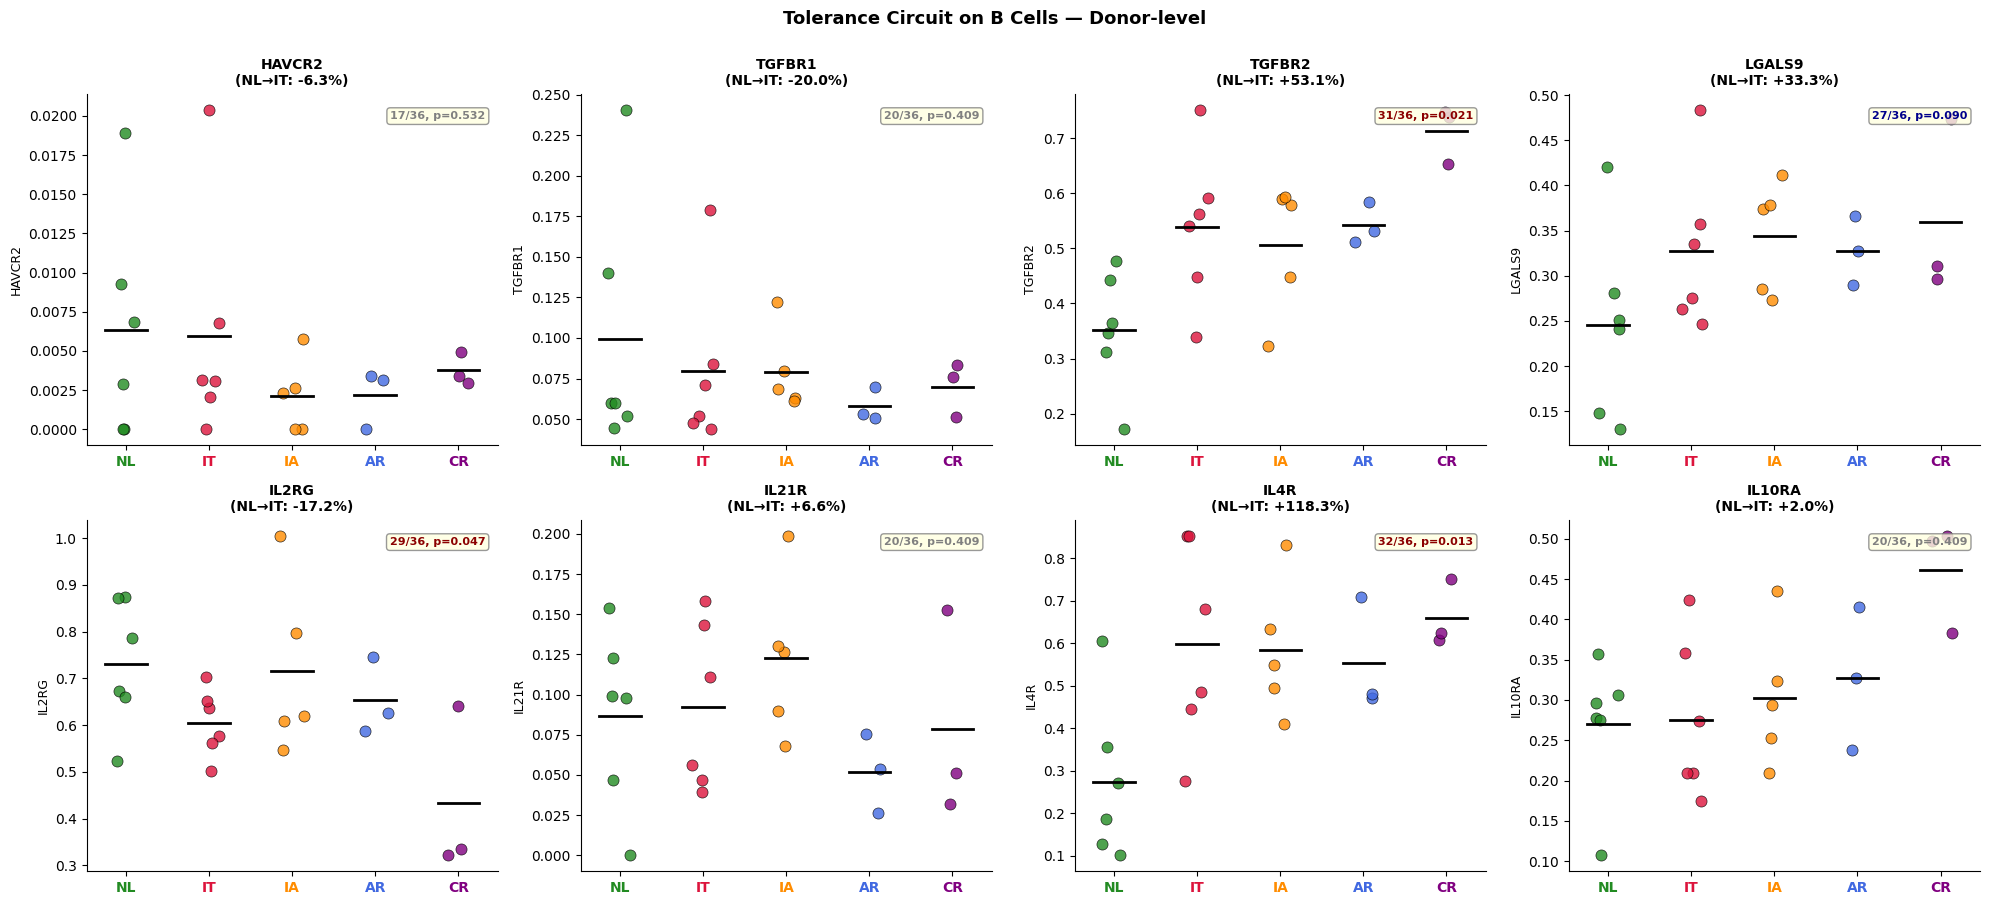

  Saved: SupFig_Bcell_ToleranceCircuit_DonorLevel


In [14]:
# ============================================================
# PART 4: TOLERANCE CIRCUIT ON B CELLS
# ============================================================
print("\n" + "="*80)
print("PART 4: TOLERANCE CIRCUIT GENES ON B CELLS")
print("        (Do B cells receive LGALS9/TGFB1 signals?)")
print("="*80)

TOLERANCE_ON_B = ['HAVCR2', 'TGFBR1', 'TGFBR2', 'LGALS9',
                   'IL2RG', 'IL21R', 'IL4R', 'IL10RA']

tol_genes_exist = [g for g in TOLERANCE_ON_B if g in adata_b.var_names]
print(f"Found: {len(tol_genes_exist)}/{len(TOLERANCE_ON_B)}")

if len(tol_genes_exist) > 0:
    tol_results = run_gene_battery(adata_b, tol_genes_exist, 'B cell (tolerance)',
                                    comparisons,
                                    'Tolerance Circuit on B Cells — Donor-level',
                                    'SupFig_Bcell_ToleranceCircuit_DonorLevel')

In [15]:
# ============================================================
# PART 5: B CELL PROPORTION — Donor-level
# ============================================================
print("\n" + "="*80)
print("PART 5: B CELL PROPORTION — DONOR-LEVEL")
print("="*80)

# Get all PBMC cells per donor per stage
all_counts = adata.obs.groupby(['donor_id', 'Stage']).size().reset_index(name='total_cells')
b_counts = adata_b.obs.groupby(['donor_id', 'Stage']).size().reset_index(name='b_cells')

prop_df = all_counts.merge(b_counts, on=['donor_id', 'Stage'], how='left')
prop_df['b_cells'] = prop_df['b_cells'].fillna(0)
prop_df['expression'] = prop_df['b_cells'] / prop_df['total_cells'] * 100

print("\nB cell proportion (%) by stage:")
for stage in STAGE_ORDER:
    sd = prop_df[prop_df['Stage'] == stage]
    if len(sd) > 0:
        print(f"  {stage}: {sd['expression'].mean():.1f}% ± {sd['expression'].std():.1f}% "
              f"(n={len(sd)} donors)")

for sa, sb in [('NL', 'IT'), ('NL', 'CR')]:
    result = donor_test(prop_df, sa, sb)
    sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""
    print(f"  {sa}→{sb}: {result['change']:+.1f}%, {result['consist']}/{result['total']}, "
          f"p={result['p']:.3f}{sig}")

print("\n" + "="*80)
print("B CELL ANALYSIS COMPLETE")
print("="*80)



PART 5: B CELL PROPORTION — DONOR-LEVEL

B cell proportion (%) by stage:
  NL: 4.7% ± 4.6% (n=23 donors)
  IT: 8.1% ± 2.6% (n=23 donors)
  IA: 7.6% ± 4.5% (n=23 donors)
  AR: 5.6% ± 2.1% (n=23 donors)
  CR: 16.8% ± 1.8% (n=23 donors)
  NL→IT: +inf%, 28/529, p=nan
  NL→CR: +inf%, 18/529, p=nan

B CELL ANALYSIS COMPLETE
